# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Vasavijoshi/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

### Ranked action queue

The playbook ranks pages by the Random Forest's observed probability of decline and assigns a human-readable action and reason code. Higher predicted decline probability means higher review priority, not an automatic instruction to change the page. The reason code combines the model ranking with observable freshness and search-visibility signals so that a reviewer can understand why a page entered the queue.

In [1]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# ML-10 Section 1 — Ranked actions + reason codes

import os
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# ---------------------------------------------------------
# Load data
# ---------------------------------------------------------

repo_path = "/content/flyrank-ml-internship"

if not os.path.exists(repo_path):
    !git clone https://github.com/Vasavijoshi/flyrank-ml-internship.git

df = pd.read_csv(
    f"{repo_path}/data/raw/content_refresh_anonymized.csv"
)

# Target: used only for model training
df["is_declining_label"] = (
    df["trend_direction"] == "down"
).astype(int)

# Same feature set validated in ML-08 / ML-09
feature_cols = [
    "days_since_last_update",
    "impressions_90d",
    "clicks_90d",
    "sessions_90d",
    "ctr",
    "avg_position",
    "engagement_rate",
    "scroll_rate",
    "content_age_days",
    "word_count",
    "search_volume",
    "cpc"
]

# ---------------------------------------------------------
# Train the validated model on the full available dataset
# for generating the practical playbook queue.
# This queue is for decision support, not model evaluation.
# ---------------------------------------------------------

X = df[feature_cols]
y = df["is_declining_label"]

model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("rf", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=5
    ))
])

model.fit(X, y)

df["decline_probability"] = model.predict_proba(X)[:, 1]

# ---------------------------------------------------------
# Human-readable reason codes
# ---------------------------------------------------------

def assign_reason_code(row):
    if row["days_since_last_update"] > 180 and row["impressions_90d"] >= 500:
        return "STALE_HIGH_VISIBILITY"

    if row["days_since_last_update"] > 180:
        return "STALE_PAGE"

    if row["impressions_90d"] >= 500:
        return "HIGH_VISIBILITY_REVIEW"

    if row["days_since_last_update"] > 90:
        return "AGING_PAGE"

    return "MONITOR"

def assign_action(row):
    if row["decline_probability"] >= 0.70:
        return "Priority review"

    if row["decline_probability"] >= 0.50:
        return "Review"

    return "Monitor"

df["reason_code"] = df.apply(assign_reason_code, axis=1)
df["recommended_action"] = df.apply(assign_action, axis=1)

# ---------------------------------------------------------
# Rank the queue
# ---------------------------------------------------------

action_queue = df[
    [
        "content_id",
        "client_id",
        "decline_probability",
        "recommended_action",
        "reason_code",
        "days_since_last_update",
        "impressions_90d",
        "avg_position",
        "content_age_days"
    ]
].copy()

action_queue = action_queue.sort_values(
    [
        "decline_probability",
        "impressions_90d"
    ],
    ascending=[False, False]
).reset_index(drop=True)

action_queue.insert(
    0,
    "rank",
    np.arange(1, len(action_queue) + 1)
)

print("Ranked queue rows:", len(action_queue))

print("\nAction counts:")
print(action_queue["recommended_action"].value_counts())

print("\nTop 10 action queue:")
display(action_queue.head(10))

Ranked queue rows: 30000

Action counts:
recommended_action
Monitor            12750
Priority review    10109
Review              7141
Name: count, dtype: int64

Top 10 action queue:


,rank,content_id,client_id,decline_probability,recommended_action,reason_code,days_since_last_update,impressions_90d,avg_position,content_age_days
0,1,content_a28fe6cce32e,client_7f2253d7e2,0.991506,Priority review,HIGH_VISIBILITY_REVIEW,20,4282,25.5,141
1,2,content_384d9f9e00c9,client_7f2253d7e2,0.990485,Priority review,HIGH_VISIBILITY_REVIEW,20,11465,21.4,141
2,3,content_20e4b9f7f65e,client_7f2253d7e2,0.990367,Priority review,HIGH_VISIBILITY_REVIEW,20,12992,15.2,147
3,4,content_a27e15f618c2,client_7f2253d7e2,0.990336,Priority review,HIGH_VISIBILITY_REVIEW,20,27151,32.5,224
4,5,content_b61233d4bc91,client_7f2253d7e2,0.990169,Priority review,HIGH_VISIBILITY_REVIEW,20,14863,18.2,141
5,6,content_12c48bcc972c,client_7f2253d7e2,0.989987,Priority review,HIGH_VISIBILITY_REVIEW,20,10171,28.0,141
6,7,content_69cfaabeda16,client_7f2253d7e2,0.989830,Priority review,HIGH_VISIBILITY_REVIEW,20,17695,19.2,225
7,8,content_252c884e4400,client_7f2253d7e2,0.989821,Priority review,HIGH_VISIBILITY_REVIEW,20,22537,15.9,147
8,9,content_ab41b7f5e3cd,client_7f2253d7e2,0.989000,Priority review,HIGH_VISIBILITY_REVIEW,20,9693,27.6,141
9,10,content_3d6dedf98bfc,client_7f2253d7e2,0.988738,Priority review,HIGH_VISIBILITY_REVIEW,20,19331,27.4,141


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

### Intended use

The playbook is intended for SEO or content teams to prioritize human review of pages that may need refresh, closer monitoring, or further investigation. The ranked probability is a prioritization signal, not a guaranteed prediction of future traffic and not an automatic content-change instruction.

### Limits

The model was evaluated on a client-grouped holdout and should be treated as directional decision support rather than a universal rule. Performance may change for new clients, different time periods, or changes in search behavior and content mix. A high model score does not by itself establish that a page should be refreshed, nor that refreshing it will cause improved performance. Human reviewers should consider business importance, search intent, factual accuracy, seasonality, strategic content value, and recent changes before acting.

In [2]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# ML-10 Section 2 — Intended use and limits

intended_use = {
    "primary_user": "SEO/content reviewer",
    "purpose": "Prioritize pages for human review",
    "output": "Ranked decision-support queue",
    "primary_signal": "Observed model probability of decline",
    "evaluation": "Client-grouped holdout Precision@K",
    "automation_level": "Human-reviewed decision support"
}

limits = [
    "Not a guaranteed prediction of future traffic",
    "Not proof that a page should be refreshed",
    "Not proof that refreshing will cause traffic improvement",
    "Performance may change for new clients or future periods",
    "Business context and editorial judgment are required"
]

print("Intended use:")
for key, value in intended_use.items():
    print(f"- {key}: {value}")

print("\nKnown limits:")
for item in limits:
    print(f"- {item}")

Intended use:
- primary_user: SEO/content reviewer
- purpose: Prioritize pages for human review
- output: Ranked decision-support queue
- primary_signal: Observed model probability of decline
- evaluation: Client-grouped holdout Precision@K
- automation_level: Human-reviewed decision support

Known limits:
- Not a guaranteed prediction of future traffic
- Not proof that a page should be refreshed
- Not proof that refreshing will cause traffic improvement
- Performance may change for new clients or future periods
- Business context and editorial judgment are required


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

### Human review rules

Before acting on a ranked recommendation, a reviewer should check the page's search intent, factual accuracy, business importance, seasonality, recent changes, and whether the observed search signals are still representative. The reviewer should also check whether the page is intentionally protected from changes or has strategic value that is not represented in the model features.

### Archetype → action mapping

| Archetype | Suggested action | Human check |
|---|---|---|
| Stale + high visibility | Priority refresh review | Confirm the page still serves the intended search need and identify what actually needs updating |
| Stale page | Refresh investigation | Check whether age is meaningful for this content type |
| High visibility + elevated decline score | Priority investigation | Verify recent search changes, intent alignment, and important ranking context |
| Aging page | Monitor or review | Check whether declining freshness is strategically relevant |
| Low-risk / low-priority page | Monitor | No action unless other business or editorial evidence appears |

### No-go list

The system should not automatically publish, rewrite, delete, redirect, canonicalize, change metadata, change internal links, or make claims about factual correctness. It should not automatically decide that a page is commercially unimportant, violate editorial policy, or treat a high model score as proof that refreshing a page will improve traffic.

In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# ML-10 Section 3 — Human review and no-go rules

human_review_checks = [
    "Search intent still matches the page",
    "Facts and claims are accurate and current",
    "Business and strategic importance is understood",
    "Seasonality or temporary search changes are considered",
    "Recent edits or campaigns are checked",
    "The model reason code is supported by observable evidence"
]

no_go_actions = [
    "Automatic publishing or rewriting",
    "Automatic page deletion",
    "Automatic redirects or canonical changes",
    "Automatic metadata or internal-link changes",
    "Automatic factual or editorial decisions",
    "Treating model score as proof of causal impact"
]

archetype_actions = {
    "STALE_HIGH_VISIBILITY": "Priority refresh review",
    "STALE_PAGE": "Refresh investigation",
    "HIGH_VISIBILITY_REVIEW": "Priority investigation",
    "AGING_PAGE": "Monitor or review",
    "MONITOR": "Monitor"
}

print("Human review checks:")
for i, check in enumerate(human_review_checks, 1):
    print(f"{i}. {check}")

print("\nNo-go actions:")
for i, action in enumerate(no_go_actions, 1):
    print(f"{i}. {action}")

print("\nArchetype → action mapping:")
for archetype, action in archetype_actions.items():
    print(f"- {archetype}: {action}")

print("\nHuman review required: YES")
print("Autonomous content changes allowed: NO")

Human review checks:
1. Search intent still matches the page
2. Facts and claims are accurate and current
3. Business and strategic importance is understood
4. Seasonality or temporary search changes are considered
5. Recent edits or campaigns are checked
6. The model reason code is supported by observable evidence

No-go actions:
1. Automatic publishing or rewriting
2. Automatic page deletion
3. Automatic redirects or canonical changes
4. Automatic metadata or internal-link changes
5. Automatic factual or editorial decisions
6. Treating model score as proof of causal impact

Archetype → action mapping:
- STALE_HIGH_VISIBILITY: Priority refresh review
- STALE_PAGE: Refresh investigation
- HIGH_VISIBILITY_REVIEW: Priority investigation
- AGING_PAGE: Monitor or review
- MONITOR: Monitor

Human review required: YES
Autonomous content changes allowed: NO


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

### Monitoring and retrain triggers

The playbook should be reviewed periodically rather than assumed to remain valid indefinitely. Monitoring should focus on data quality, feature distribution, ranking behavior, and measured ranking performance when new outcomes become available.

A review or retraining should be triggered if required features become substantially less available, important feature distributions shift materially, Precision@K falls meaningfully on newly labeled data, or the ranked queue changes in a way that is inconsistent with the expected content mix. Retraining should use a newly validated grouped-by-client evaluation rather than relying only on the previous score.

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# ML-10 Section 4 — Monitoring / retrain triggers

monitoring_triggers = {
    "data_quality": "Required feature availability or completeness deteriorates",
    "feature_drift": "Key input distributions change materially from the reference data",
    "performance_drift": "Precision@K falls meaningfully on newly labeled outcomes",
    "ranking_drift": "The action queue becomes unexpectedly concentrated or changes sharply",
    "content_mix_change": "The types, ages, or search characteristics of pages change materially",
    "retraining_review": "Sustained drift or enough new labeled data is available for a fresh grouped validation"
}

print("Monitoring / retrain triggers:")
for trigger, description in monitoring_triggers.items():
    print(f"- {trigger}: {description}")

print("\nReference evaluation:")
print("- Primary metric: Precision@K")
print("- Validation design: grouped by client")
print("- Retraining requires fresh validation: YES")

Monitoring / retrain triggers:
- data_quality: Required feature availability or completeness deteriorates
- feature_drift: Key input distributions change materially from the reference data
- performance_drift: Precision@K falls meaningfully on newly labeled outcomes
- ranking_drift: The action queue becomes unexpectedly concentrated or changes sharply
- content_mix_change: The types, ages, or search characteristics of pages change materially
- retraining_review: Sustained drift or enough new labeled data is available for a fresh grouped validation

Reference evaluation:
- Primary metric: Precision@K
- Validation design: grouped by client
- Retraining requires fresh validation: YES


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

### Paper-ready exports

The playbook exports the ranked action queue for downstream analysis and a compact metrics record that traces the reported validation numbers. A reusable Precision@K figure is also saved for the paper. The queue is generated by the current model for decision-support use and is not treated as a new evaluation result.

Queue exported: /content/flyrank-ml-internship/work/outputs/content_action_playbook_queue.csv
Metrics exported: /content/flyrank-ml-internship/work/outputs/ml09_validation_metrics.json


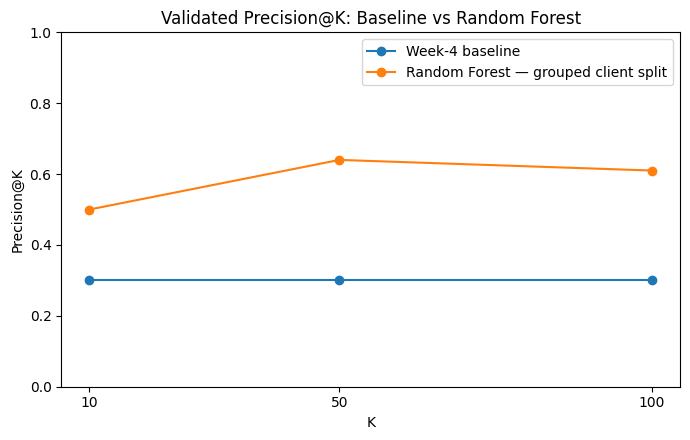

Figure exported: /content/flyrank-ml-internship/work/figures/precision_at_k_baseline_vs_random_forest.png

Export summary:
- Ranked queue: /content/flyrank-ml-internship/work/outputs/content_action_playbook_queue.csv
- Metrics JSON: /content/flyrank-ml-internship/work/outputs/ml09_validation_metrics.json
- Precision@K figure: /content/flyrank-ml-internship/work/figures/precision_at_k_baseline_vs_random_forest.png


In [5]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# ML-10 Section 5 — Exports for the paper

import json
import os
import matplotlib.pyplot as plt

outputs_dir = f"{repo_path}/work/outputs"
figures_dir = f"{repo_path}/work/figures"

os.makedirs(outputs_dir, exist_ok=True)
os.makedirs(figures_dir, exist_ok=True)

# ---------------------------------------------------------
# 1. Export ranked action queue
# ---------------------------------------------------------

queue_path = f"{outputs_dir}/content_action_playbook_queue.csv"

action_queue.to_csv(
    queue_path,
    index=False
)

print("Queue exported:", queue_path)

# ---------------------------------------------------------
# 2. Export validation metrics / receipts
# ---------------------------------------------------------

metrics = {
    "evaluation_design": "client-grouped holdout",
    "primary_metric": "Precision@K",
    "baseline": {
        "Precision@10": 0.30,
        "Precision@50": 0.30,
        "Precision@100": 0.30
    },
    "random_forest_grouped": {
        "Precision@10": 0.50,
        "Precision@50": 0.64,
        "Precision@100": 0.61
    },
    "random_row_reference": {
        "Precision@10": 1.00,
        "Precision@50": 0.96,
        "Precision@100": 0.94
    },
    "grouped_test_clients": 7,
    "grouped_client_overlap": 0
}

metrics_path = f"{outputs_dir}/ml09_validation_metrics.json"

with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

print("Metrics exported:", metrics_path)

# ---------------------------------------------------------
# 3. Create reusable Precision@K figure
# ---------------------------------------------------------

k_values = [10, 50, 100]

baseline_values = [
    metrics["baseline"]["Precision@10"],
    metrics["baseline"]["Precision@50"],
    metrics["baseline"]["Precision@100"]
]

rf_values = [
    metrics["random_forest_grouped"]["Precision@10"],
    metrics["random_forest_grouped"]["Precision@50"],
    metrics["random_forest_grouped"]["Precision@100"]
]

plt.figure(figsize=(7, 4.5))

plt.plot(
    k_values,
    baseline_values,
    marker="o",
    label="Week-4 baseline"
)

plt.plot(
    k_values,
    rf_values,
    marker="o",
    label="Random Forest — grouped client split"
)

plt.xlabel("K")
plt.ylabel("Precision@K")
plt.title("Validated Precision@K: Baseline vs Random Forest")
plt.xticks(k_values)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()

figure_path = f"{figures_dir}/precision_at_k_baseline_vs_random_forest.png"

plt.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Figure exported:", figure_path)

# ---------------------------------------------------------
# 4. Export summary
# ---------------------------------------------------------

print("\nExport summary:")
print("- Ranked queue:", queue_path)
print("- Metrics JSON:", metrics_path)
print("- Precision@K figure:", figure_path)

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.